# 유럽 vs 한국 뷰티 트렌드 텍스트마이닝 — 완전 실행 가능한 데모

- 외부 API/스크래핑/유료 패키지 없이 즉시 실행되도록 '내장 샘플 데이터'를 사용한다.
- 표준 라이브러리 + scikit-learn + pandas + matplotlib 만 사용한다.
- 한국어 형태소 분석기(KoNLPy 등)는 설치가 까다로워, 데모에서는 '경량 토크나이저'로 대체한다.
  (실데이터 단계에서 어떻게 교체하는지는 문서 본문에서 설명한다.)

In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")  # 화면 없는 환경에서도 그림 파일 저장 가능
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

RANDOM_STATE = 42  # 재현성: 같은 결과가 다시 나오도록 난수 고정

## [0] 내장 샘플 데이터

- market: 'KR'(한국) / 'EU'(유럽)
- brand: 브랜드명
- text: 소비자 리뷰(데모용으로 직접 작성한 가상의 짧은 리뷰)
- 실제 프로젝트에서는 이 DataFrame을 '수집한 리뷰'로 바꾸기만 하면 된다.

In [19]:
def load_sample_reviews():
    rows = [
        # ---- 한국(KR): 보습/순함/성분/속건조/저자극 키워드가 자주 등장하도록 구성 ----
        ("KR", "AURA", "수분 보습 진짜 좋고 순해서 민감성 피부에도 자극 없이 잘 맞아요"),
        ("KR", "AURA", "성분이 순하고 촉촉한 마무리라 속건조 없이 하루종일 편안했어요"),
        ("KR", "AURA", "향이 은은하고 발림성 좋아서 데일리로 쓰기 좋아요 가성비 최고"),
        ("KR", "NOVA", "저자극 처방이라 트러블 없이 순하게 흡수되고 보습력도 만족"),
        ("KR", "NOVA", "촉촉한데 끈적임 없고 순해서 재구매 의사 있어요 자극 전혀 없음"),
        ("KR", "NOVA", "수분 가득 채워주는 느낌 성분 꼼꼼히 봤는데 안심하고 쓸 수 있어요"),
        ("KR", "LUMI", "발림성 좋고 흡수 빠르고 보습 유지력 좋아서 건조한 환절기에 딱"),
        ("KR", "LUMI", "순하고 촉촉 자극없이 매일 쓰기 좋은 데일리 보습 제품"),
        ("KR", "LUMI", "가성비 좋고 향도 적당해서 부담없이 꾸준히 쓰는 중이에요"),
        ("KR", "AURA", "민감성인데도 자극없이 순하게 보습 잘 되고 진정되는 느낌"),
        ("KR", "NOVA", "속건조 잡아주고 촉촉함 오래가서 겨울철 보습으로 추천해요"),
        ("KR", "LUMI", "성분 좋고 순한데 가격도 합리적이라 가성비 갑이라고 생각해요"),
        # ---- 유럽(EU): 지속력/향/럭셔리/패키지/퍼포먼스 키워드가 자주 등장하도록 구성 ----
        ("EU", "AURA", "long lasting hydration with a luxurious texture and elegant packaging"),
        ("EU", "AURA", "the fragrance is sophisticated and the formula feels premium and rich"),
        ("EU", "AURA", "high performance anti aging results visible after a few weeks of use"),
        ("EU", "NOVA", "luxury feel beautiful scent and the packaging looks expensive and chic"),
        ("EU", "NOVA", "long wear formula stays on all day great performance and elegant finish"),
        ("EU", "NOVA", "rich texture premium ingredients and a refined sophisticated fragrance"),
        ("EU", "LUMI", "elegant bottle luxurious experience and noticeable anti aging performance"),
        ("EU", "LUMI", "the scent is divine long lasting and the packaging is truly premium"),
        ("EU", "LUMI", "high end formula visible results sophisticated and worth the price"),
        ("EU", "AURA", "premium quality elegant design and a long lasting sophisticated perfume"),
        ("EU", "NOVA", "luxury skincare with rich performance and a beautiful refined fragrance"),
        ("EU", "LUMI", "expensive but the performance and elegant packaging justify the price"),
    ]
    return pd.DataFrame(rows, columns=["market", "brand", "text"])

## [1] 전처리 + 경량 토크나이저

- 한국어: 공백 기준 분리 + 1글자 조사/어미 제거(아주 단순한 규칙)
- 영어: 소문자화 + 단어 단위 분리
- 실데이터에서는 한국어 형태소 분석기(예: Mecab/Okt)로 교체한다(문서 본문 참고).

In [20]:
KO_STOPWORDS = {"진짜", "정말", "너무", "그냥", "조금", "약간", "하루", "하루종일", "중", "수", "것", "거", "게"}
EN_STOPWORDS = {
    "the", "and", "a", "an", "of", "to", "is", "it", "with", "for", "in", "on",
    "after", "few", "all", "but", "looks", "feels", "stays", "are", "as"
}

def tokenize_ko(text):
    """한국어 경량 토크나이저: 공백 분리 후 길이>=2 단어만, 불용어 제거."""
    tokens = re.findall(r"[가-힣]+", text)
    out = []
    for t in tokens:
        if len(t) >= 2 and t not in KO_STOPWORDS:
            out.append(t)
    return out

def tokenize_en(text):
    """영어 경량 토크나이저: 소문자화 후 단어 분리, 불용어 제거."""
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    return [t for t in tokens if len(t) >= 3 and t not in EN_STOPWORDS]

def tokenize(text, market):
    return tokenize_ko(text) if market == "KR" else tokenize_en(text)

## [2] 키워드 빈도 분석 (시장별 상위 키워드)

In [21]:
def top_keywords(df, market, n=8):
    counter = {}
    for _, row in df[df["market"] == market].iterrows():
        for tok in tokenize(row["text"], market):
            counter[tok] = counter.get(tok, 0) + 1
    s = pd.Series(counter).sort_values(ascending=False)
    return s.head(n)

## [3] 토픽 모델링 (LDA)

- 시장별로 따로 적합한다(언어가 다르므로).
- n_topics개의 '잠재 주제'를 찾아, 각 주제의 대표 단어를 출력한다.

In [22]:
def run_lda(df, market, n_topics=2, n_top_words=6):
    docs = [" ".join(tokenize(t, market)) for t in df[df["market"] == market]["text"]]
    vectorizer = CountVectorizer()
    dtm = vectorizer.fit_transform(docs)            # 문서-단어 행렬
    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=RANDOM_STATE, learning_method="batch"
    )
    lda.fit(dtm)
    vocab = np.array(vectorizer.get_feature_names_out())
    topics = []
    for k, comp in enumerate(lda.components_):
        top_idx = comp.argsort()[::-1][:n_top_words]
        topics.append((k, list(vocab[top_idx])))
    return topics

## [4] 감성 분석 (사전 기반 — 데모용)

- 긍정/부정 단어 사전으로 점수를 매긴다(가장 단순하고 투명한 방식).
- 점수 = (긍정 단어 수 - 부정 단어 수) / (총 토큰 수)  → -1 ~ +1 범위
- 실데이터에서는 KoBERT/KcBERT 같은 학습형 모델로 교체 가능(문서 본문 참고).

In [23]:
POS_WORDS = {
    # 한국어
    "좋고", "좋아요", "좋아", "최고", "촉촉", "촉촉한", "순해서", "순하고", "순한", "순하게",
    "만족", "추천", "편안", "진정", "안심", "합리적", "갑", "가성비",
    # 영어
    "luxurious", "luxury", "elegant", "premium", "sophisticated", "rich",
    "beautiful", "divine", "high", "refined", "chic", "worth", "visible", "great",
}
NEG_WORDS = {
    "자극", "끈적임", "속건조", "건조", "트러블", "부담",  # 한국어(문맥상 부정 신호로 단순화)
    "expensive",  # 영어
}
# 주의: '자극없이/자극 없음'처럼 부정어와 결합하면 긍정이지만,
#       데모에서는 규칙을 단순화한다(실데이터에서는 부정어 처리 로직 추가).

def sentiment_score(text, market):
    toks = tokenize(text, market)
    if not toks:
        return 0.0
    # 부정어 결합 보정: '자극없이','자극 없' 패턴은 긍정으로 간주
    neg_fix = ("자극없이" in text) or ("자극 없" in text) or ("없이" in text and "자극" in text)
    pos = sum(1 for t in toks if t in POS_WORDS)
    neg = sum(1 for t in toks if t in NEG_WORDS)
    if neg_fix:
        neg = max(0, neg - 1)  # '자극'이 부정으로 잘못 잡힌 것을 1회 보정
    return (pos - neg) / len(toks)

def brand_sentiment_table(df):
    df = df.copy()
    df["sent"] = [sentiment_score(t, m) for t, m in zip(df["text"], df["market"])]
    tbl = df.groupby(["market", "brand"])["sent"].mean().reset_index()
    return tbl.pivot(index="brand", columns="market", values="sent").round(4)

## [5] 시각화

(a) 시장별 상위 키워드 막대그래프
(b) 브랜드×시장 평균 감성점수 그룹 막대그래프

In [24]:
def make_figures(df, out_path="beauty_textmining_figure.png"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    # (a) KR 키워드
    kr = top_keywords(df, "KR", n=7)
    axes[0].barh(kr.index[::-1], kr.values[::-1], color="#4C72B0")
    axes[0].set_title("Top keywords — Korea (KR)", fontsize=11)
    axes[0].set_xlabel("frequency")

    # (b) EU 키워드
    eu = top_keywords(df, "EU", n=7)
    axes[1].barh(eu.index[::-1], eu.values[::-1], color="#C44E52")
    axes[1].set_title("Top keywords — Europe (EU)", fontsize=11)
    axes[1].set_xlabel("frequency")

    # (c) 브랜드별 감성 비교
    tbl = brand_sentiment_table(df)
    x = np.arange(len(tbl.index))
    w = 0.38
    axes[2].bar(x - w/2, tbl["KR"].values, width=w, label="KR", color="#4C72B0")
    axes[2].bar(x + w/2, tbl["EU"].values, width=w, label="EU", color="#C44E52")
    axes[2].set_xticks(x); axes[2].set_xticklabels(tbl.index)
    axes[2].axhline(0, color="gray", linewidth=0.8)
    axes[2].set_title("Avg. sentiment by brand & market", fontsize=11)
    axes[2].set_ylabel("sentiment (-1 ~ +1)")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    print(f"[saved] {out_path}")
    return out_path


## [6] 메인 파이프라인

In [25]:
def main():
    df = load_sample_reviews()
    print("=" * 70)
    print(f"[데이터] 리뷰 {len(df)}건 / 시장 {df['market'].nunique()}개 / 브랜드 {df['brand'].nunique()}개")
    print("=" * 70)

    print("\n[1] 시장별 상위 키워드")
    print("- 한국(KR):", dict(top_keywords(df, "KR", n=6)))
    print("- 유럽(EU):", dict(top_keywords(df, "EU", n=6)))

    print("\n[2] 토픽 모델링(LDA) 결과")
    for mk in ["KR", "EU"]:
        print(f"  [{mk}]")
        for k, words in run_lda(df, mk, n_topics=2, n_top_words=5):
            print(f"    - Topic {k}: {', '.join(words)}")

    print("\n[3] 브랜드×시장 평균 감성점수 (-1 ~ +1)")
    print(brand_sentiment_table(df).to_string())

    print("\n[4] 시각화 저장")
    make_figures(df)

    print("\n완료. (실데이터 적용 시 load_sample_reviews()만 교체하면 됨)")


if __name__ == "__main__":
    main()

[데이터] 리뷰 24건 / 시장 2개 / 브랜드 3개

[1] 시장별 상위 키워드
- 한국(KR): {'보습': np.int64(4), '좋고': np.int64(4), '없이': np.int64(3), '가성비': np.int64(3), '순해서': np.int64(2), '순하고': np.int64(2)}
- 유럽(EU): {'elegant': np.int64(5), 'performance': np.int64(5), 'premium': np.int64(4), 'packaging': np.int64(4), 'sophisticated': np.int64(4), 'long': np.int64(4)}

[2] 토픽 모델링(LDA) 결과
  [KR]
    - Topic 0: 좋고, 없이, 가성비, 자극, 순해서
    - Topic 1: 보습, 쓰기, 자극없이, 좋아서, 발림성
  [EU]
    - Topic 0: sophisticated, fragrance, rich, formula, premium
    - Topic 1: elegant, long, packaging, performance, lasting

[3] 브랜드×시장 평균 감성점수 (-1 ~ +1)
market      EU      KR
brand                 
AURA    0.3777  0.2103
LUMI    0.2589  0.2083
NOVA    0.4196  0.0018

[4] 시각화 저장


/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5060/1187781848.py:28: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_lay

[saved] beauty_textmining_figure.png

완료. (실데이터 적용 시 load_sample_reviews()만 교체하면 됨)


## 시장별 감성함수 히스토그램

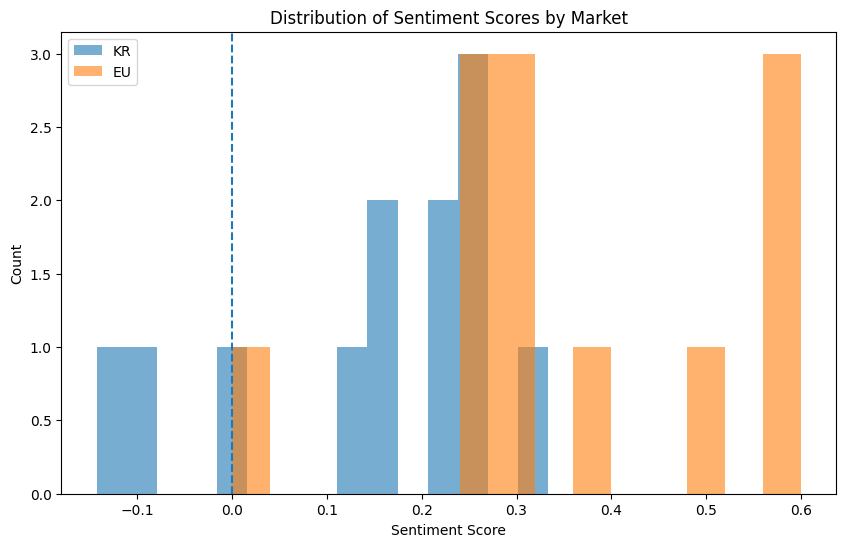

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import re # Needed for tokenize functions

# --- Dependencies for load_sample_reviews (from cell ea070ec1) ---
def load_sample_reviews():
    rows = [
        # ---- 한국(KR): 보습/순함/성분/속건조/저자극 키워드가 자주 등장하도록 구성 ----
        ("KR", "AURA", "수분 보습 진짜 좋고 순해서 민감성 피부에도 자극 없이 잘 맞아요"),
        ("KR", "AURA", "성분이 순하고 촉촉한 마무리라 속건조 없이 하루종일 편안했어요"),
        ("KR", "AURA", "향이 은은하고 발림성 좋아서 데일리로 쓰기 좋아요 가성비 최고"),
        ("KR", "NOVA", "저자극 처방이라 트러블 없이 순하게 흡수되고 보습력도 만족"),
        ("KR", "NOVA", "촉촉한데 끈적임 없고 순해서 재구매 의사 있어요 자극 전혀 없음"),
        ("KR", "NOVA", "수분 가득 채워주는 느낌 성분 꼼꼼히 봤는데 안심하고 쓸 수 있어요"),
        ("KR", "LUMI", "발림성 좋고 흡수 빠르고 보습 유지력 좋아서 건조한 환절기에 딱"),
        ("KR", "LUMI", "순하고 촉촉 자극없이 매일 쓰기 좋은 데일리 보습 제품"),
        ("KR", "LUMI", "가성비 좋고 향도 적당해서 부담없이 꾸준히 쓰는 중이에요"),
        ("KR", "AURA", "민감성인데도 자극없이 순하게 보습 잘 되고 진정되는 느낌"),
        ("KR", "NOVA", "속건조 잡아주고 촉촉함 오래가서 겨울철 보습으로 추천해요"),
        ("KR", "LUMI", "성분 좋고 순한데 가격도 합리적이라 가성비 갑이라고 생각해요"),
        # ---- 유럽(EU): 지속력/향/럭셔리/패키지/퍼포먼스 키워드가 자주 등장하도록 구성 ----
        ("EU", "AURA", "long lasting hydration with a luxurious texture and elegant packaging"),
        ("EU", "AURA", "the fragrance is sophisticated and the formula feels premium and rich"),
        ("EU", "AURA", "high performance anti aging results visible after a few weeks of use"),
        ("EU", "NOVA", "luxury feel beautiful scent and the packaging looks expensive and chic"),
        ("EU", "NOVA", "long wear formula stays on all day great performance and elegant finish"),
        ("EU", "NOVA", "rich texture premium ingredients and a refined sophisticated fragrance"),
        ("EU", "LUMI", "elegant bottle luxurious experience and noticeable anti aging performance"),
        ("EU", "LUMI", "the scent is divine long lasting and the packaging is truly premium"),
        ("EU", "LUMI", "high end formula visible results sophisticated and worth the price"),
        ("EU", "AURA", "premium quality elegant design and a long lasting sophisticated perfume"),
        ("EU", "NOVA", "luxury skincare with rich performance and a beautiful refined fragrance"),
        ("EU", "LUMI", "expensive but the performance and elegant packaging justify the price"),
    ]
    return pd.DataFrame(rows, columns=["market", "brand", "text"])

# --- Dependencies for sentiment_score (tokenize, stopwords, pos/neg words from cells 09f29a2d and 473f020f) ---
KO_STOPWORDS = {"진짜", "정말", "너무", "그냥", "조금", "약간", "하루", "하루종일", "중", "수", "것", "거", "게"}
EN_STOPWORDS = {
    "the", "and", "a", "an", "of", "to", "is", "it", "with", "for", "in", "on",
    "after", "few", "all", "but", "looks", "feels", "stays", "are", "as"
}

def tokenize_ko(text):
    tokens = re.findall(r"[가-힣]+", text)
    out = []
    for t in tokens:
        if len(t) >= 2 and t not in KO_STOPWORDS:
            out.append(t)
    return out

def tokenize_en(text):
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    return [t for t in tokens if len(t) >= 3 and t not in EN_STOPWORDS]

def tokenize(text, market):
    return tokenize_ko(text) if market == "KR" else tokenize_en(text)

POS_WORDS = {
    "좋고", "좋아요", "좋아", "최고", "촉촉", "촉촉한", "순해서", "순하고", "순한", "순하게",
    "만족", "추천", "편안", "진정", "안심", "합리적", "갑", "가성비",
    "luxurious", "luxury", "elegant", "premium", "sophisticated", "rich",
    "beautiful", "divine", "high", "refined", "chic", "worth", "visible", "great",
}
NEG_WORDS = {
    "자극", "끈적임", "속건조", "건조", "트러블", "부담",
    "expensive",
}

def sentiment_score(text, market):
    toks = tokenize(text, market)
    if not toks:
        return 0.0
    neg_fix = ("자극없이" in text) or ("자극 없" in text) or ("없이" in text and "자극" in text)
    pos = sum(1 for t in toks if t in POS_WORDS)
    neg = sum(1 for t in toks if t in NEG_WORDS)
    if neg_fix:
        neg = max(0, neg - 1)
    return (pos - neg) / len(toks)

# --- Data loading and sentiment score calculation ---
df = load_sample_reviews()
df["sentiment_score"] = [sentiment_score(t, m) for t, m in zip(df["text"], df["market"])]

# --- Original plotting code ---
plt.figure(figsize=(10,6))

# KR
plt.hist(
    df[df["market"]=="KR"]["sentiment_score"],
    bins=15,
    alpha=0.6,
    label="KR"
)

# EU
plt.hist(
    df[df["market"]=="EU"]["sentiment_score"],
    bins=15,
    alpha=0.6,
    label="EU"
)

plt.axvline(0, linestyle="--")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.title("Distribution of Sentiment Scores by Market")
plt.legend()
plt.show()

## 브랜드별 바이올린 플롯

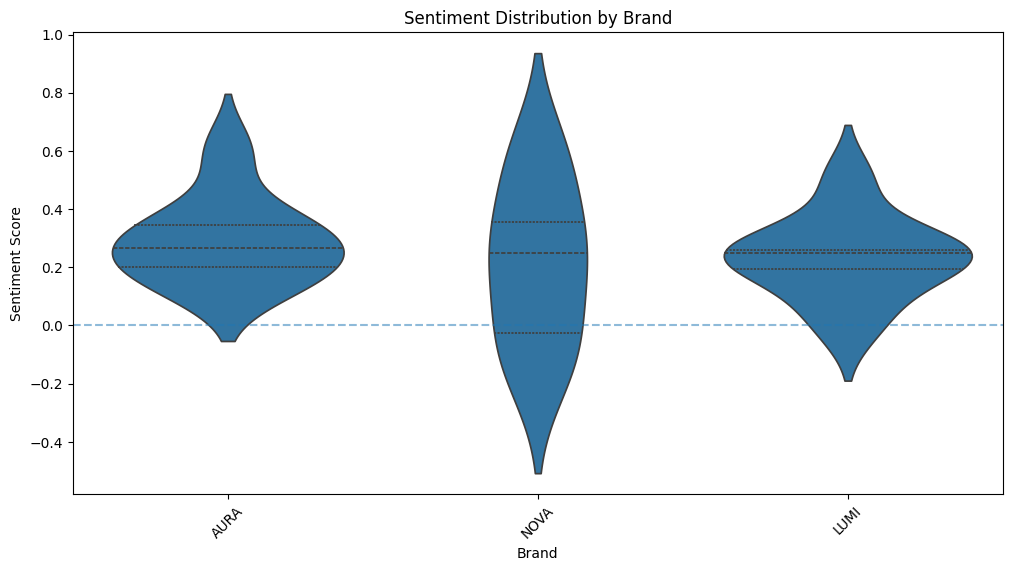

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="brand",
    y="sentiment_score",
    inner="quartile"
)

plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Sentiment Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)

plt.show()

# 시장별 바이올린 플롯 (KR vs EU 비교)

/tmp/ipykernel_5060/3272863728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


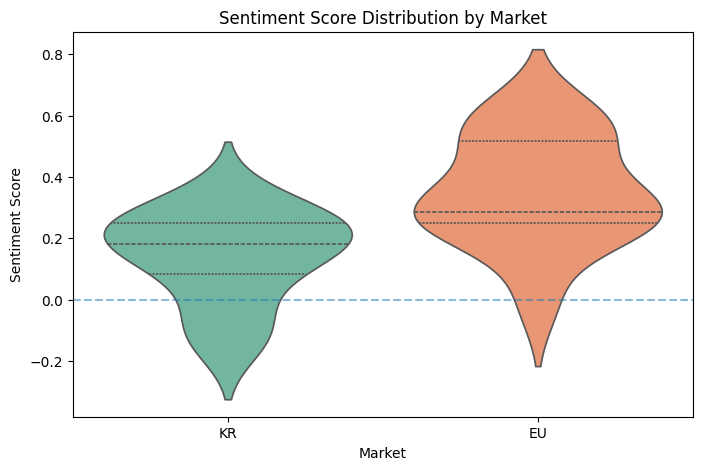

In [33]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="market",
    y="sentiment_score",
    palette="Set2",
    inner="quartile"
)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Sentiment Score Distribution by Market")
plt.xlabel("Market")
plt.ylabel("Sentiment Score")

plt.show()

# 브랜드별 평균 감성점수 막대그래프

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

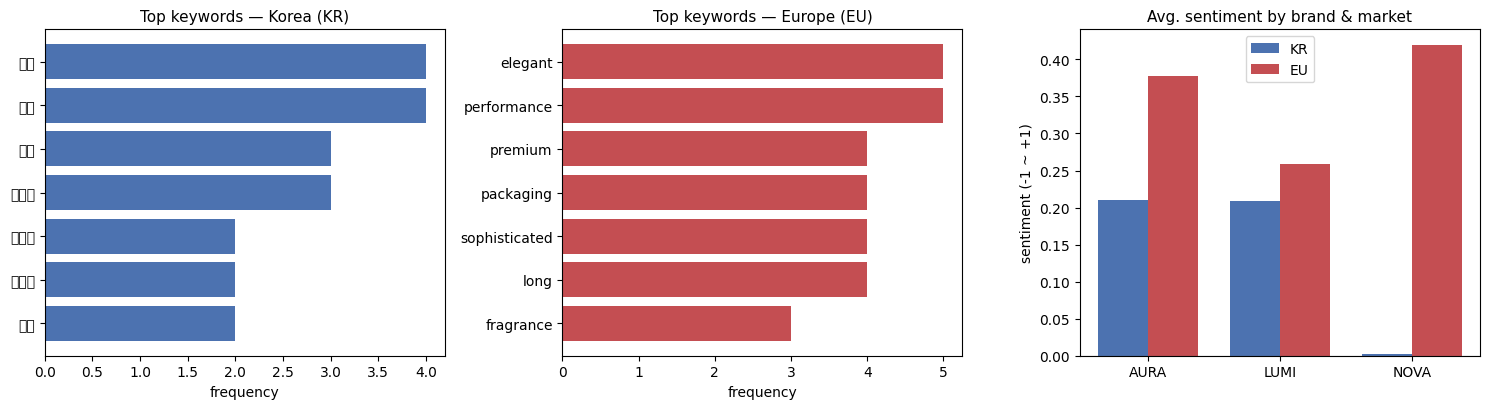

<Figure size 1000x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

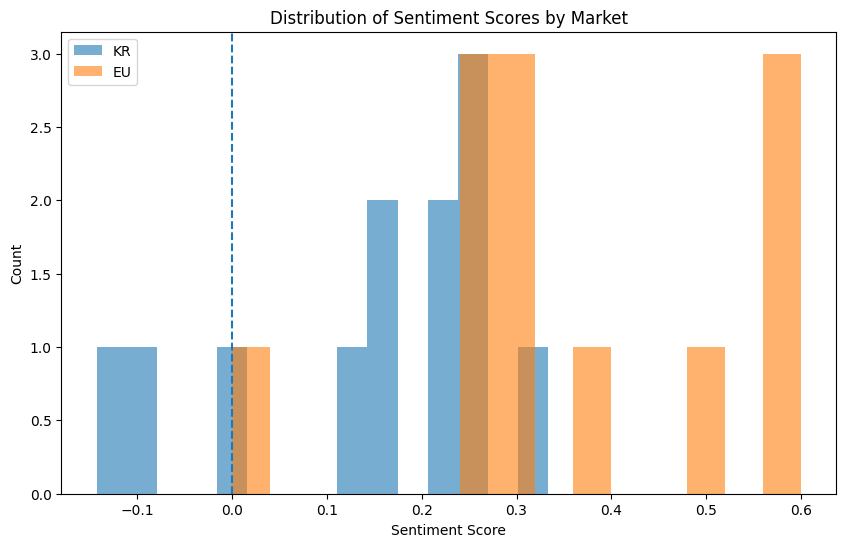

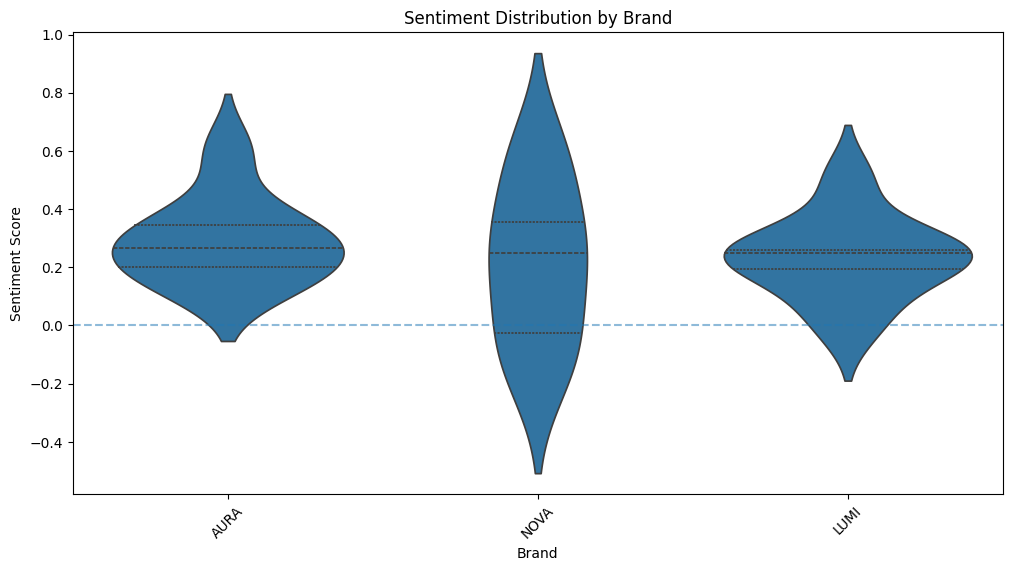

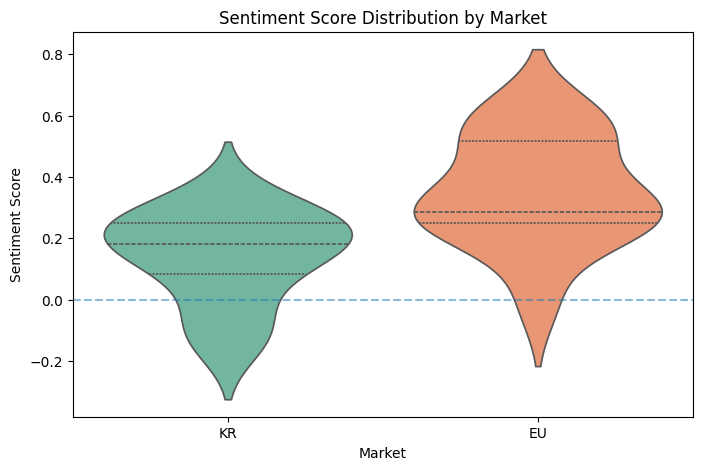

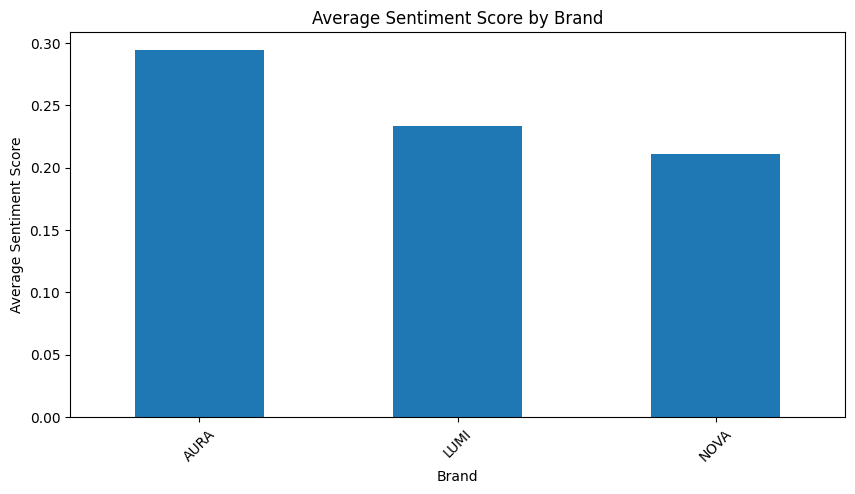

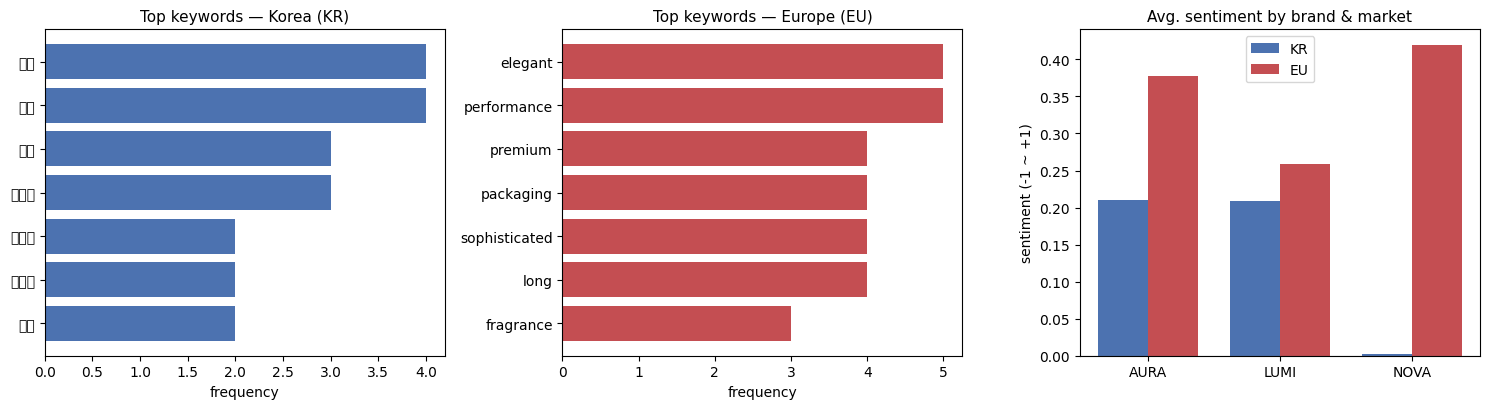

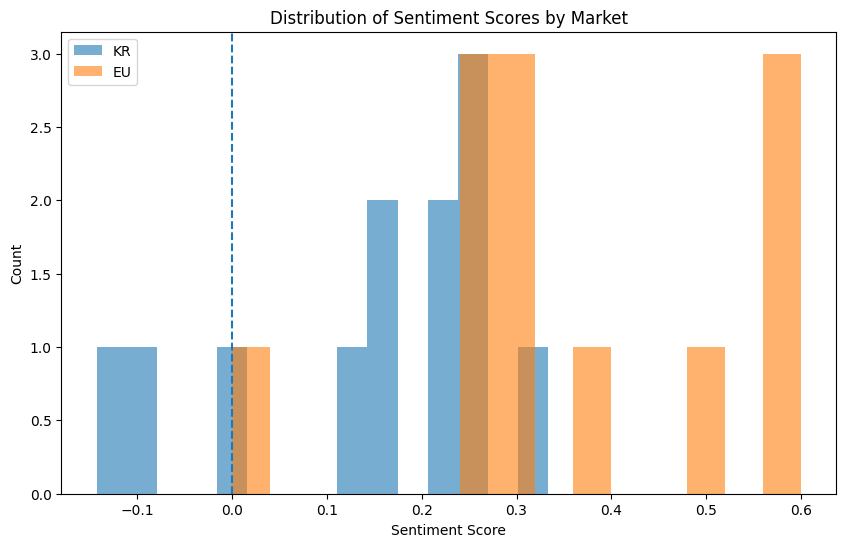

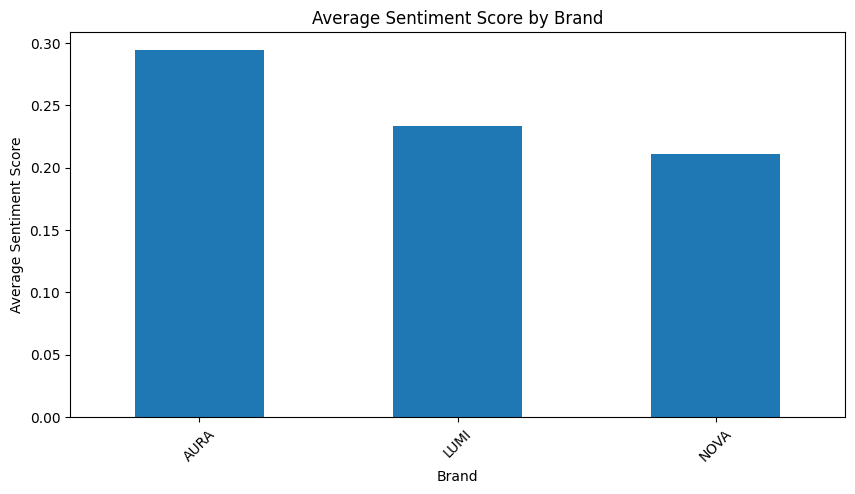

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 노트북에서 그래프 바로 보이게 설정
%matplotlib inline

df = load_sample_reviews()

# 감성점수 컬럼 생성
df["sentiment_score"] = [
    sentiment_score(text, market)
    for text, market in zip(df["text"], df["market"])
]

df.head()
brand_avg = (
    df.groupby("brand")["sentiment_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

brand_avg.plot(kind="bar")

plt.title("Average Sentiment Score by Brand")
plt.ylabel("Average Sentiment Score")
plt.xlabel("Brand")
plt.xticks(rotation=45)

plt.show()